**Verify NVIDIA GPU Availability**

Select "Runtime" -> "Change runtime type" in the top menu bar, Select T4

In [ ]:
!pip install -q -U ultralytics pyyaml

import torch
import ultralytics

print("Ultralytics:", ultralytics.__version__)
print("CUDA disponível:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    raise RuntimeError(
        "GPU não detectada. No Colab, selecione Runtime > Change runtime type > T4 GPU."
    )



Ultralytics: 8.4.163
CUDA disponível: True
GPU: Tesla T4


definir caminhos

In [ ]:
from pathlib import Path
import yaml

DATASET_ROOT = Path("/content/Dataset")
DATA_YAML = DATASET_ROOT / "data.yaml"

TRAIN_IMAGES = DATASET_ROOT / "train" / "images"
VALID_IMAGES = DATASET_ROOT / "valid" / "images"
TEST_IMAGES = DATASET_ROOT / "test" / "images"

TRAIN_LABELS = DATASET_ROOT / "train" / "labels"
VALID_LABELS = DATASET_ROOT / "valid" / "labels"
TEST_LABELS = DATASET_ROOT / "test" / "labels"

for path in [
    DATASET_ROOT,
    DATA_YAML,
    TRAIN_IMAGES,
    VALID_IMAGES,
    TEST_IMAGES,
    TRAIN_LABELS,
    VALID_LABELS,
    TEST_LABELS,
]:
    print(f"{path}: {'OK' if path.exists() else 'NÃO ENCONTRADO'}")


/content/Dataset: OK
/content/Dataset/data.yaml: NÃO ENCONTRADO
/content/Dataset/train/images: OK
/content/Dataset/valid/images: OK
/content/Dataset/test/images: OK
/content/Dataset/train/labels: OK
/content/Dataset/valid/labels: OK
/content/Dataset/test/labels: OK


ccorrigir data.yaml

In [ ]:
data_config = {
    "path": str(DATASET_ROOT),
    "train": "train/images",
    "val": "valid/images",
    "test": "test/images",
    "nc": 4,
    "names": {
        0: "ball",
        1: "goalkeeper",
        2: "player",
        3: "referee",
    },
}

with open(DATA_YAML, "w") as f:
    yaml.safe_dump(data_config, f, sort_keys=False)

print(DATA_YAML.read_text())


path: /content/Dataset
train: train/images
val: valid/images
test: test/images
nc: 4
names:
  0: ball
  1: goalkeeper
  2: player
  3: referee



Verificar imagens

In [ ]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def list_images(path):
    return sorted([
        p for p in Path(path).rglob("*")
        if p.suffix.lower() in IMAGE_EXTENSIONS
    ])

def list_labels(path):
    return sorted(Path(path).rglob("*.txt"))

for split, image_dir, label_dir in [
    ("train", TRAIN_IMAGES, TRAIN_LABELS),
    ("valid", VALID_IMAGES, VALID_LABELS),
    ("test", TEST_IMAGES, TEST_LABELS),
]:
    images = list_images(image_dir)
    labels = list_labels(label_dir)

    print(f"{split}:")
    print(f"  imagens: {len(images)}")
    print(f"  labels:  {len(labels)}")


train:
  imagens: 612
  labels:  612
valid:
  imagens: 38
  labels:  38
test:
  imagens: 13
  labels:  13


Verificar os IDs das classes

In [ ]:
valid_class_ids = {0, 1, 2, 3}
invalid_labels = []

for label_file in list_labels(DATASET_ROOT):
    try:
        for line_number, line in enumerate(label_file.read_text().splitlines(), start=1):
            line = line.strip()

            if not line:
                continue

            class_id = int(line.split()[0])

            if class_id not in valid_class_ids:
                invalid_labels.append(
                    (str(label_file), line_number, class_id)
                )

    except Exception as error:
        invalid_labels.append((str(label_file), "erro", str(error)))

if invalid_labels:
    print("Foram encontrados labels inválidos:")
    for item in invalid_labels[:20]:
        print(item)
else:
    print("Todos os IDs de classe são válidos.")


Todos os IDs de classe são válidos.


treinamento

In [ ]:
from ultralytics import YOLO

MODEL_NAME = "yolo26s.pt"

model = YOLO(MODEL_NAME)

results = model.train(
    data=str(DATA_YAML),

    epochs=150,
    imgsz=960,
    batch=-1,

    device=0,
    workers=2,

    pretrained=True,
    patience=30,

    project="/content/runs_players",
    name="player_detector",
    exist_ok=True,

    amp=True,
    cache=False,
    plots=True,
    seed=42,

    cos_lr=True,
    close_mosaic=10
)


Ultralytics 8.4.163 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/Dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=150, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=960, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=player_detector, nbs=64, nms=None, opset=None, opt

Carregar melhor modelo?

In [ ]:
from pathlib import Path
from ultralytics import YOLO

BEST_MODEL_PATH = Path(
    "/content/runs_players/player_detector/weights/best.pt"
)

if not BEST_MODEL_PATH.exists():
    raise FileNotFoundError(
        f"Modelo não encontrado em: {BEST_MODEL_PATH}"
    )

best_model = YOLO(str(BEST_MODEL_PATH))

print("Melhor modelo carregado:", BEST_MODEL_PATH)


Melhor modelo carregado: /content/runs_players/player_detector/weights/best.pt


Avaliação no teste

In [ ]:
from pathlib import Path
from ultralytics import YOLO

BEST_MODEL_PATH = Path(
    "/content/runs_players/player_detector/weights/best.pt"
)

if not BEST_MODEL_PATH.exists():
    raise FileNotFoundError(
        f"Modelo não encontrado em: {BEST_MODEL_PATH}"
    )

best_model = YOLO(str(BEST_MODEL_PATH))

print("Melhor modelo carregado:", BEST_MODEL_PATH)


Melhor modelo carregado: /content/runs_players/player_detector/weights/best.pt


previsoes no conjunto de teste

In [ ]:
prediction_results = best_model.predict(
    source=str(TEST_IMAGES),
    imgsz=960,
    conf=0.25,
    iou=0.5,

    save=True,
    save_txt=True,
    save_conf=True,

    project="/content/predictions",
    name="players",
    exist_ok=True
)

PREDICTION_DIR = Path("/content/predictions/players")
print("Resultados salvos em:", PREDICTION_DIR)



image 1/13 /content/Dataset/test/images/40cd38_7_6_png.rf.68ef7fcd663cdf0f5b96bacdbcd94e07.jpg: 544x960 1 ball, 21 players, 1 referee, 19.0ms
image 2/13 /content/Dataset/test/images/42ba34_1_5_png.rf.4337fde8fbe3640cf4351fb41ac9c3ca.jpg: 544x960 1 ball, 1 goalkeeper, 21 players, 2 referees, 19.0ms
image 3/13 /content/Dataset/test/images/42ba34_5_5_png.rf.ceb556bd4c92d41496ae1d8c56600c4a.jpg: 544x960 1 goalkeeper, 19 players, 1 referee, 19.0ms
image 4/13 /content/Dataset/test/images/4b770a_1_4_png.rf.5a45b3b841a06de414ceb802e34c136f.jpg: 544x960 1 goalkeeper, 20 players, 3 referees, 19.0ms
image 5/13 /content/Dataset/test/images/4b770a_3_6_png.rf.d0d9403f2f73ca0da7a6a1373c02b749.jpg: 544x960 1 goalkeeper, 20 players, 2 referees, 18.9ms
image 6/13 /content/Dataset/test/images/573e61_1_9_png.rf.e82af77d907cdc12dccbd6857f53b9b1.jpg: 544x960 19 players, 2 referees, 19.0ms
image 7/13 /content/Dataset/test/images/573e61_9_6_png.rf.fc52856b5974cb67862c25bae96f25ad.jpg: 544x960 1 goalkeeper, 2

resultado das predições

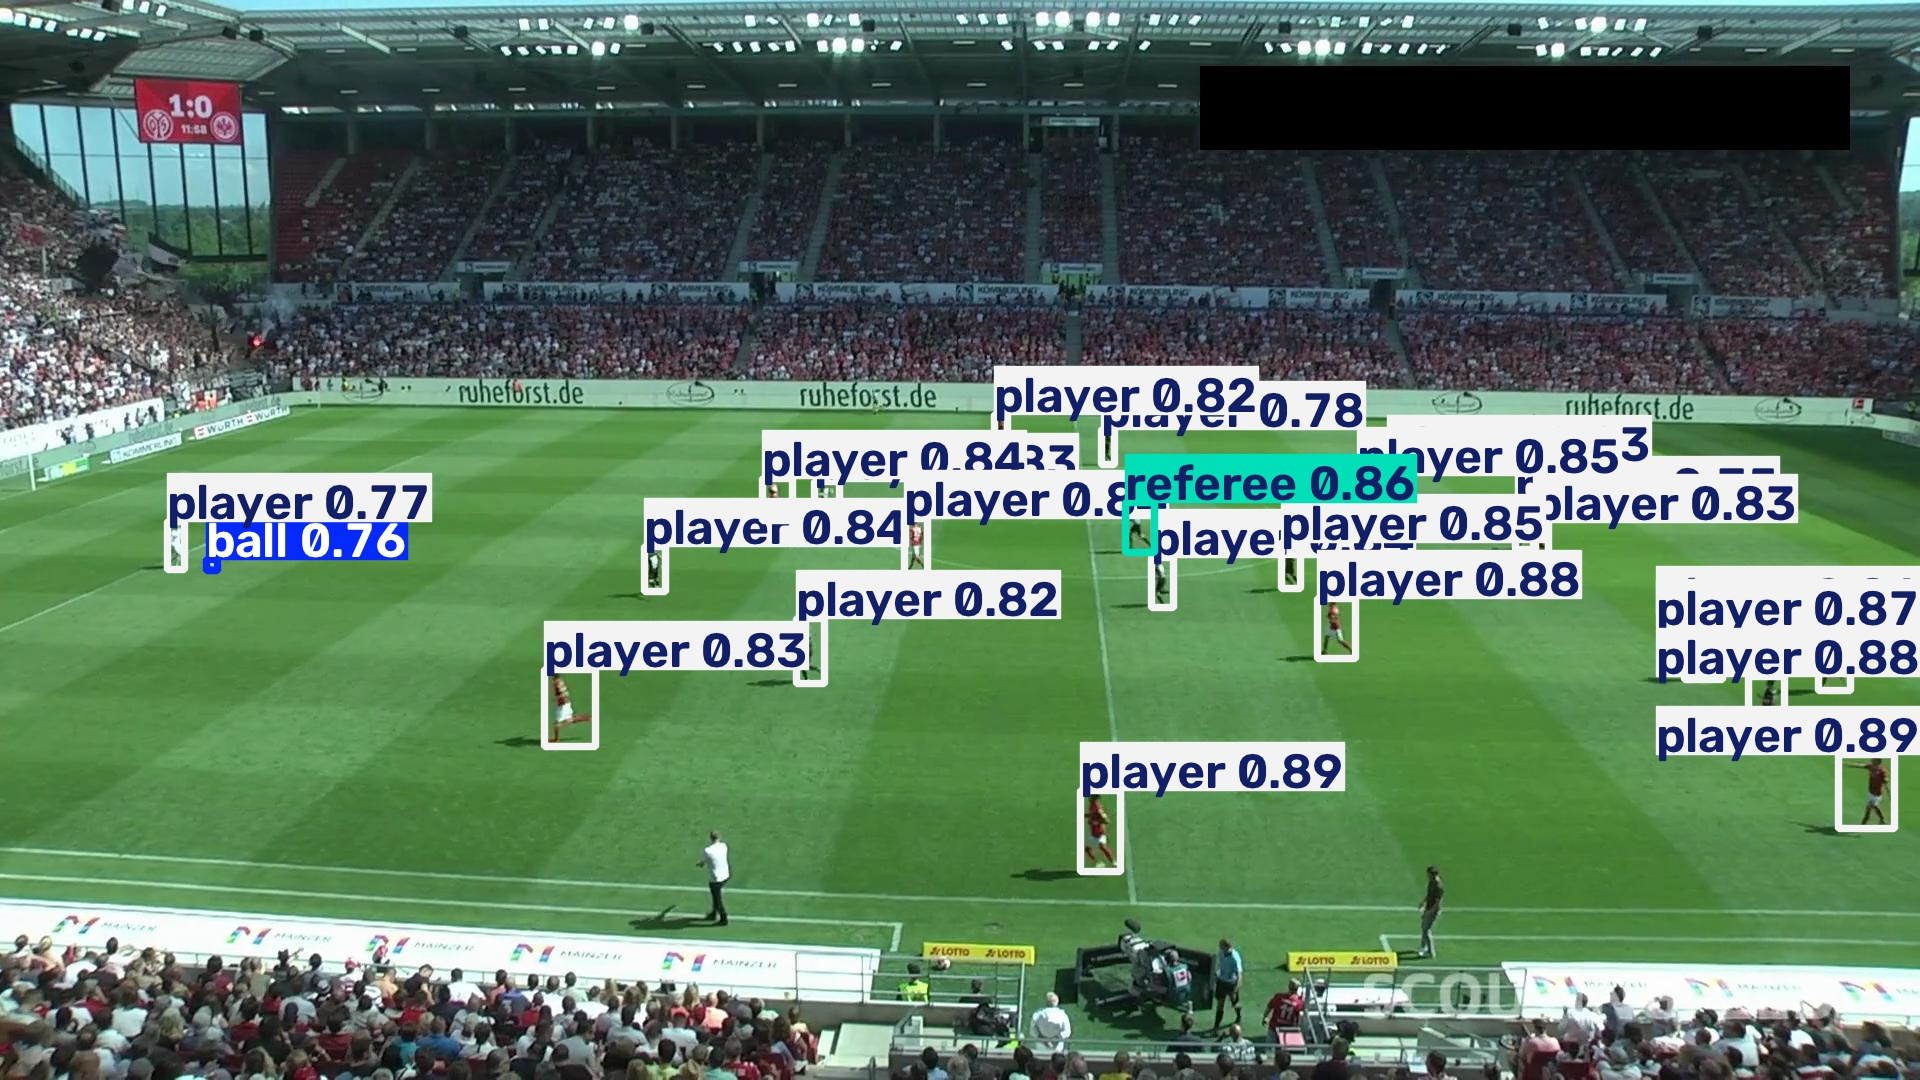

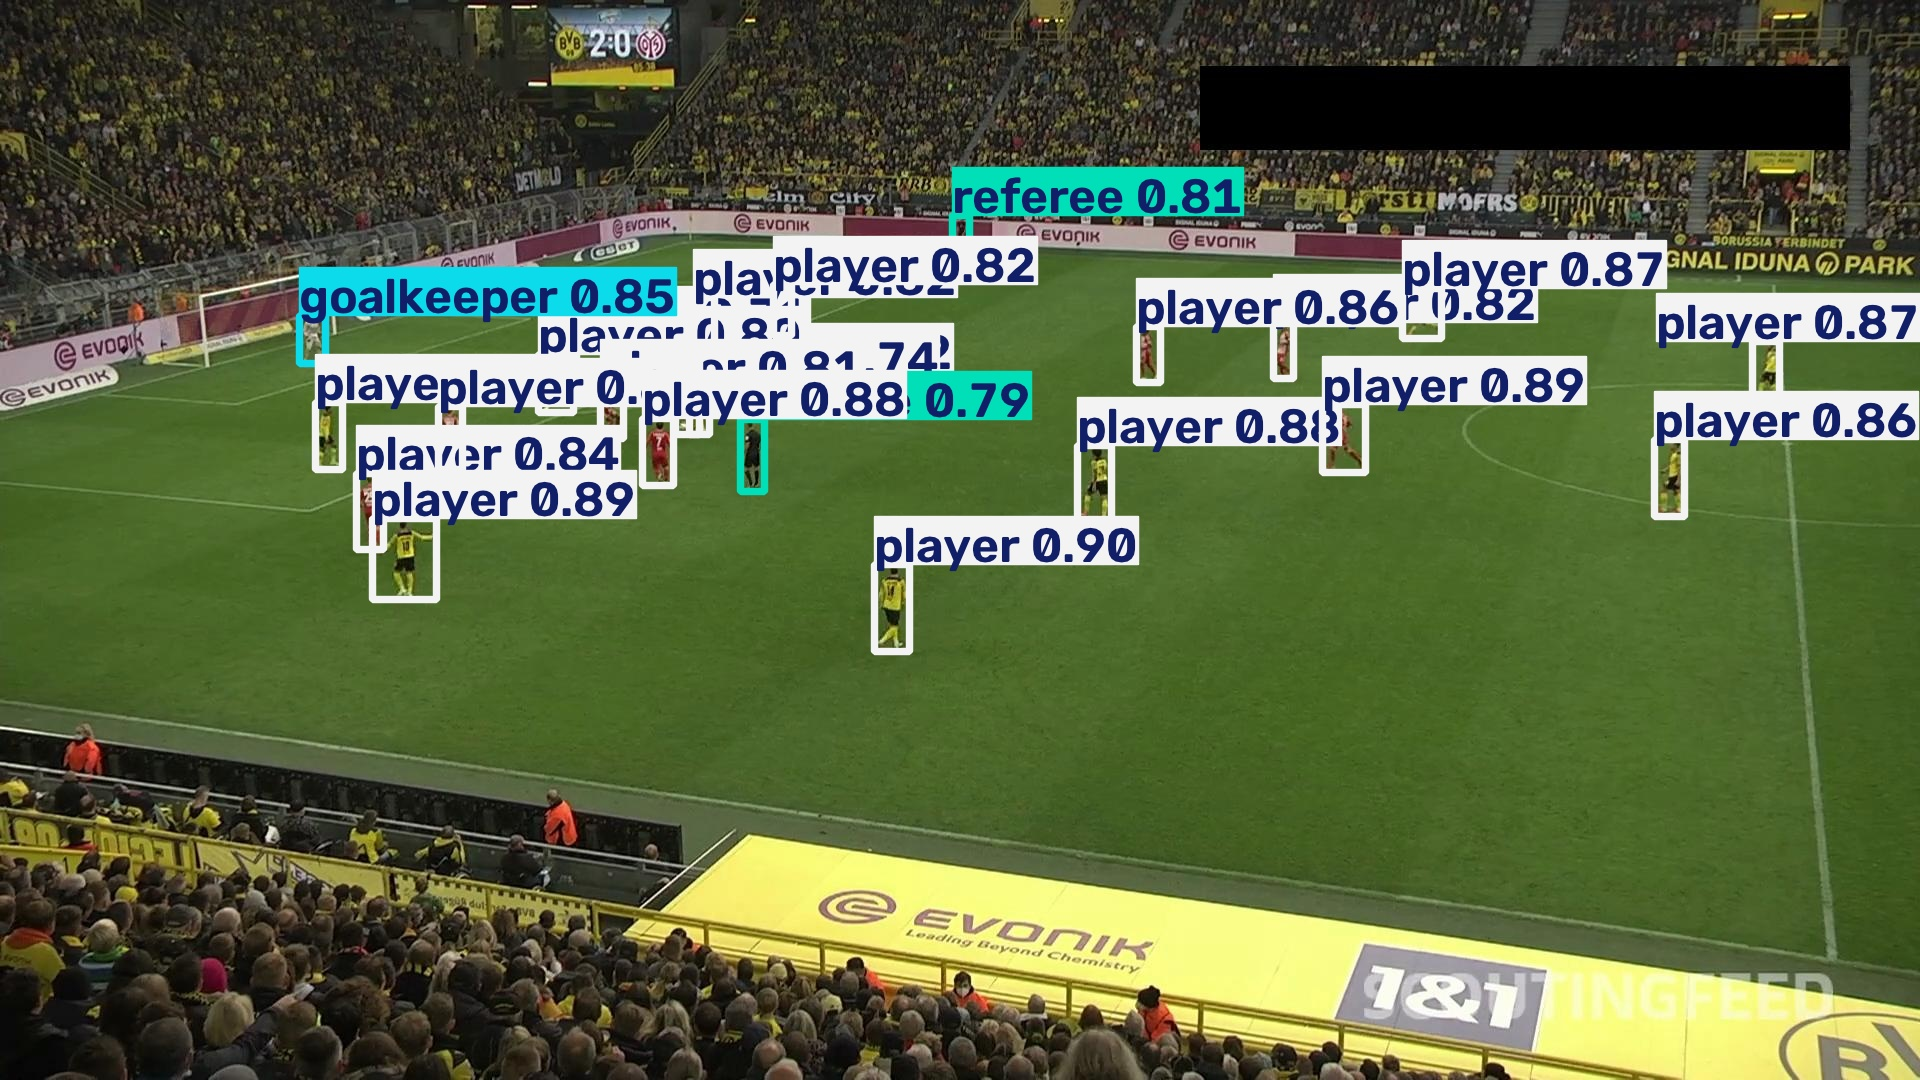

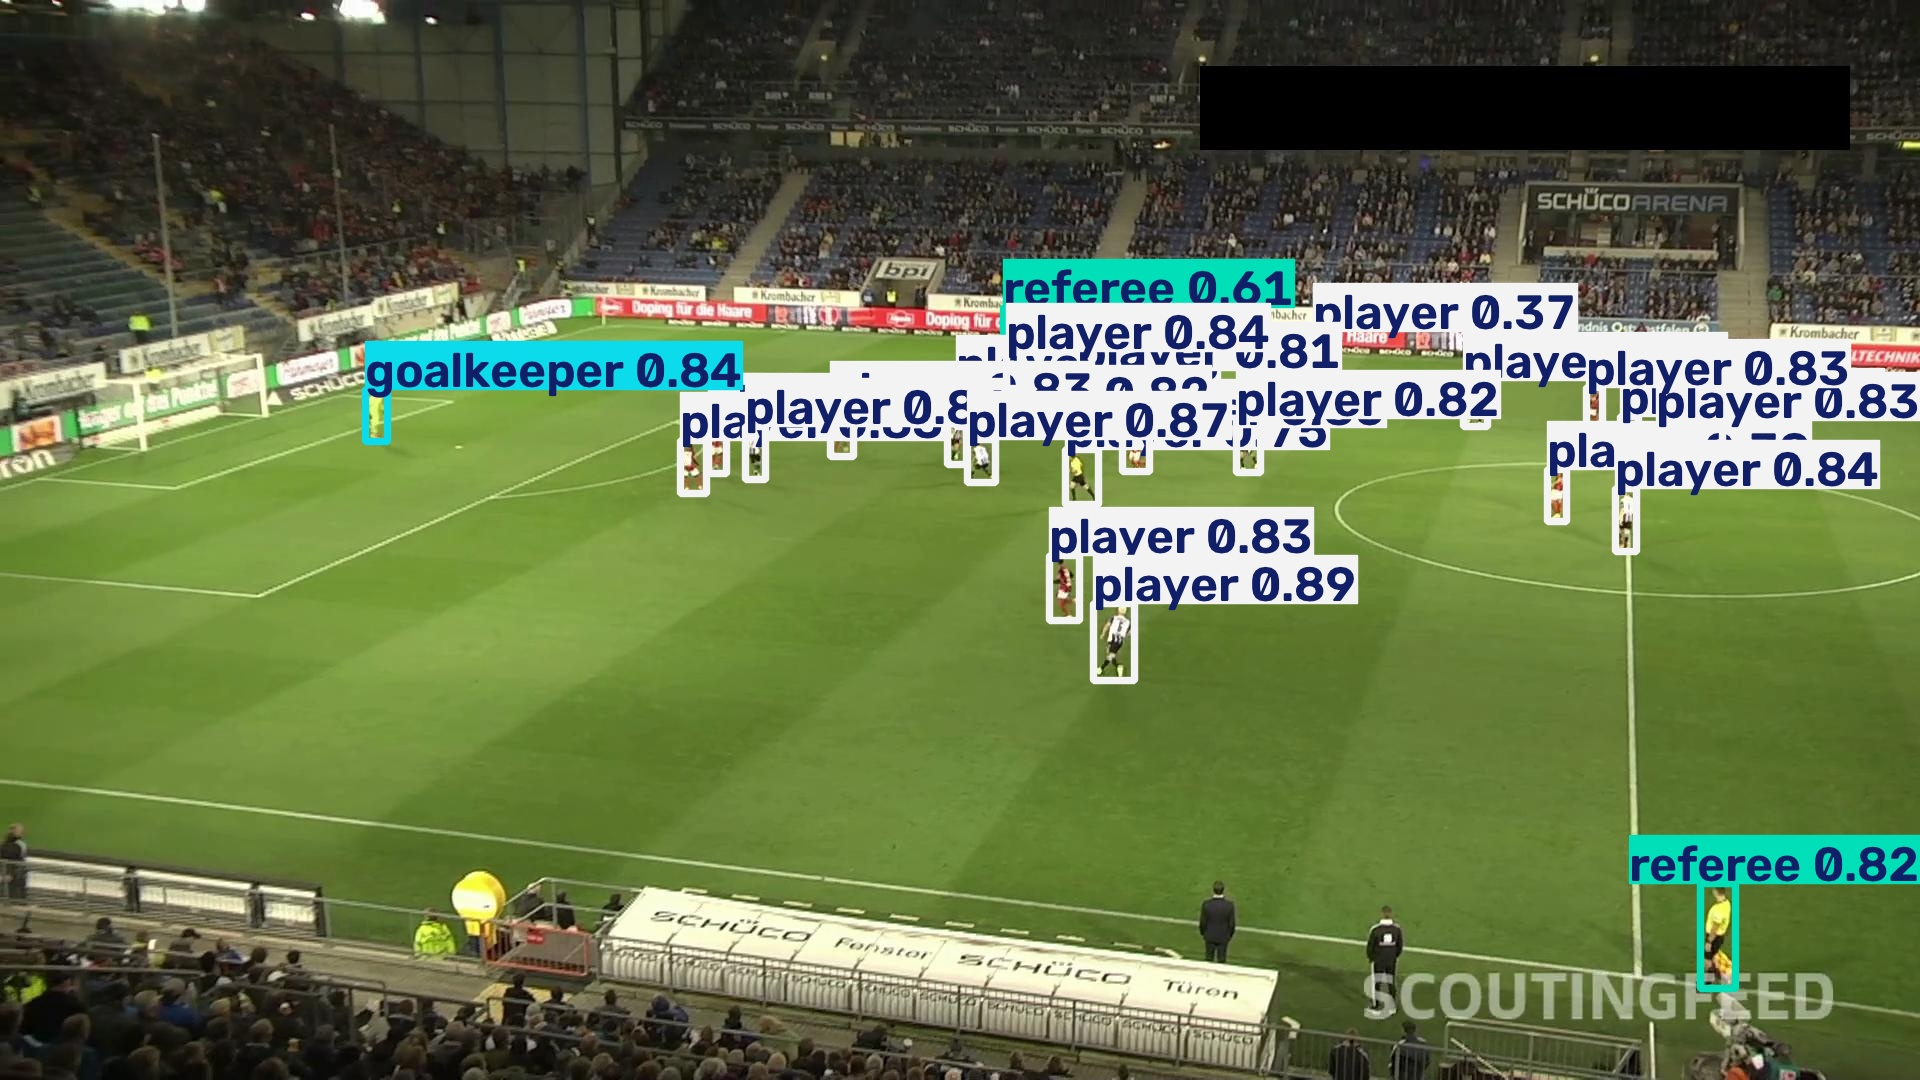

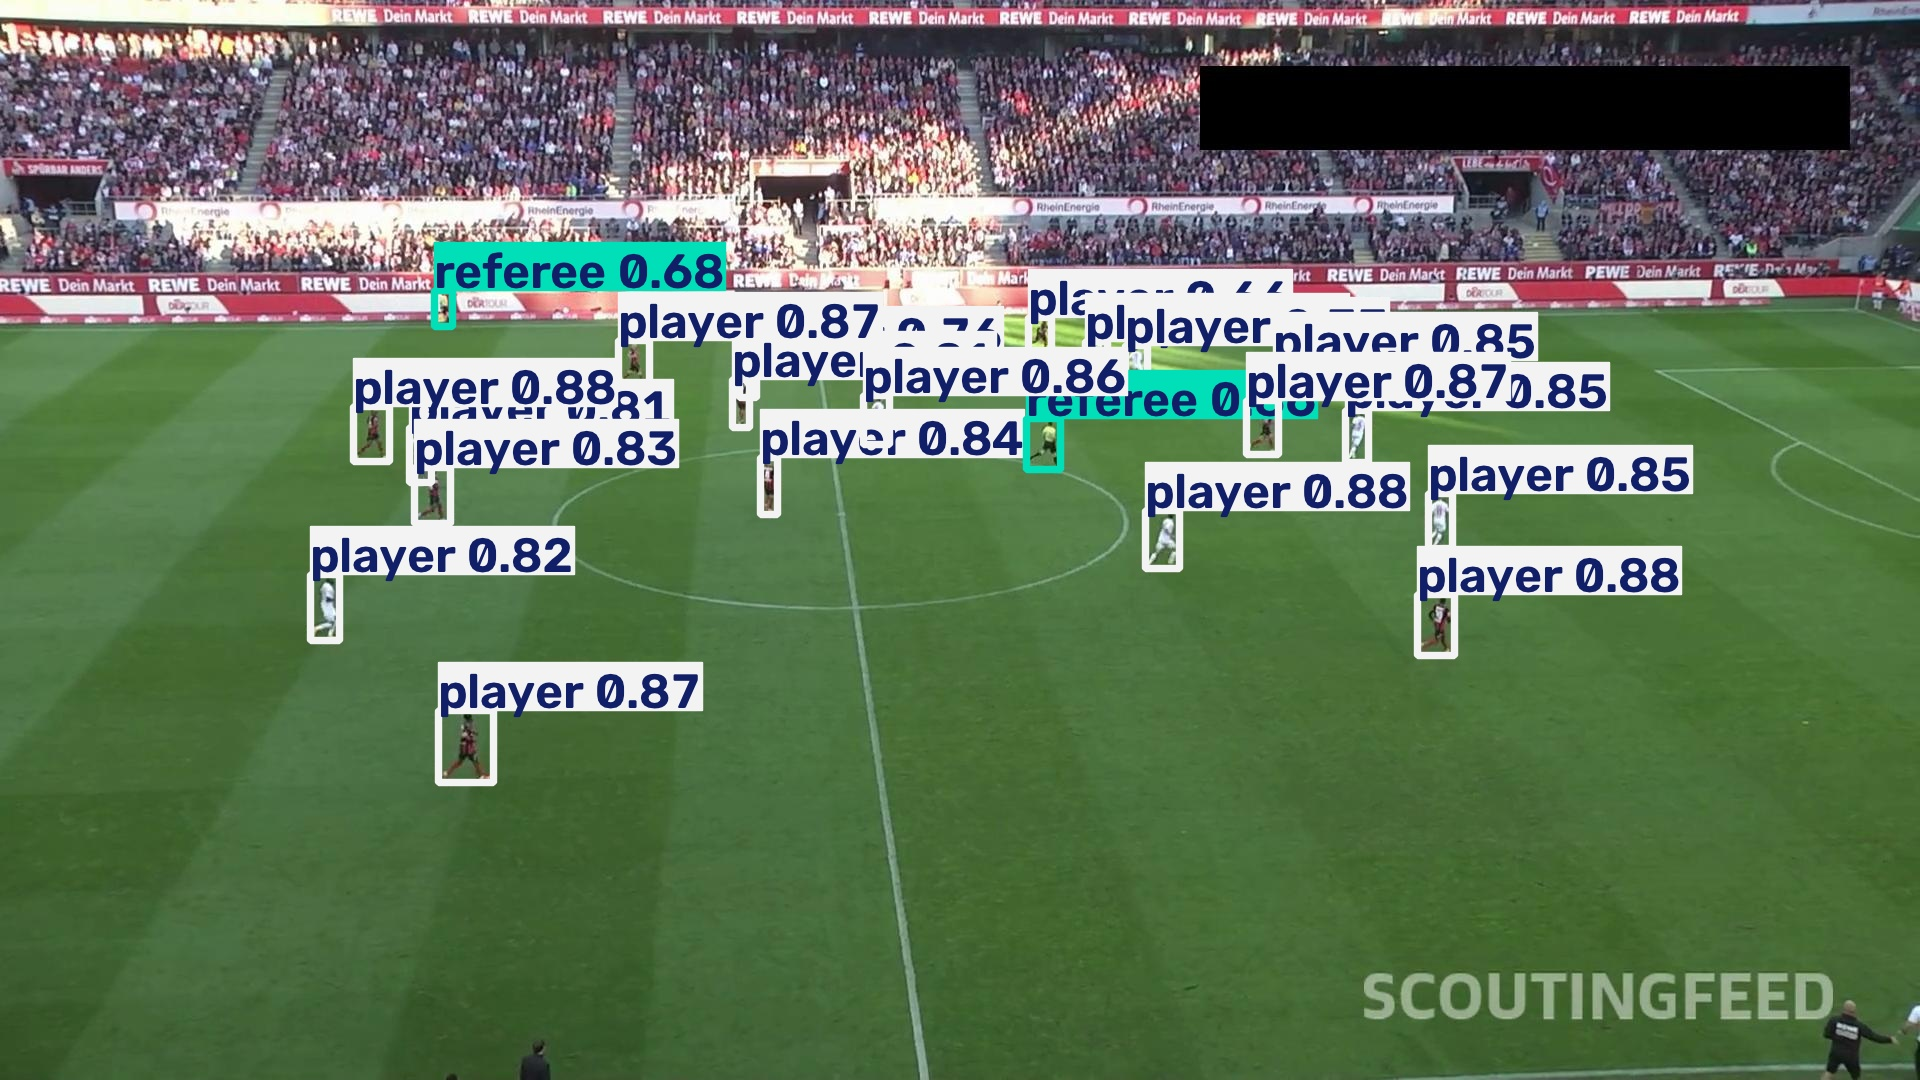

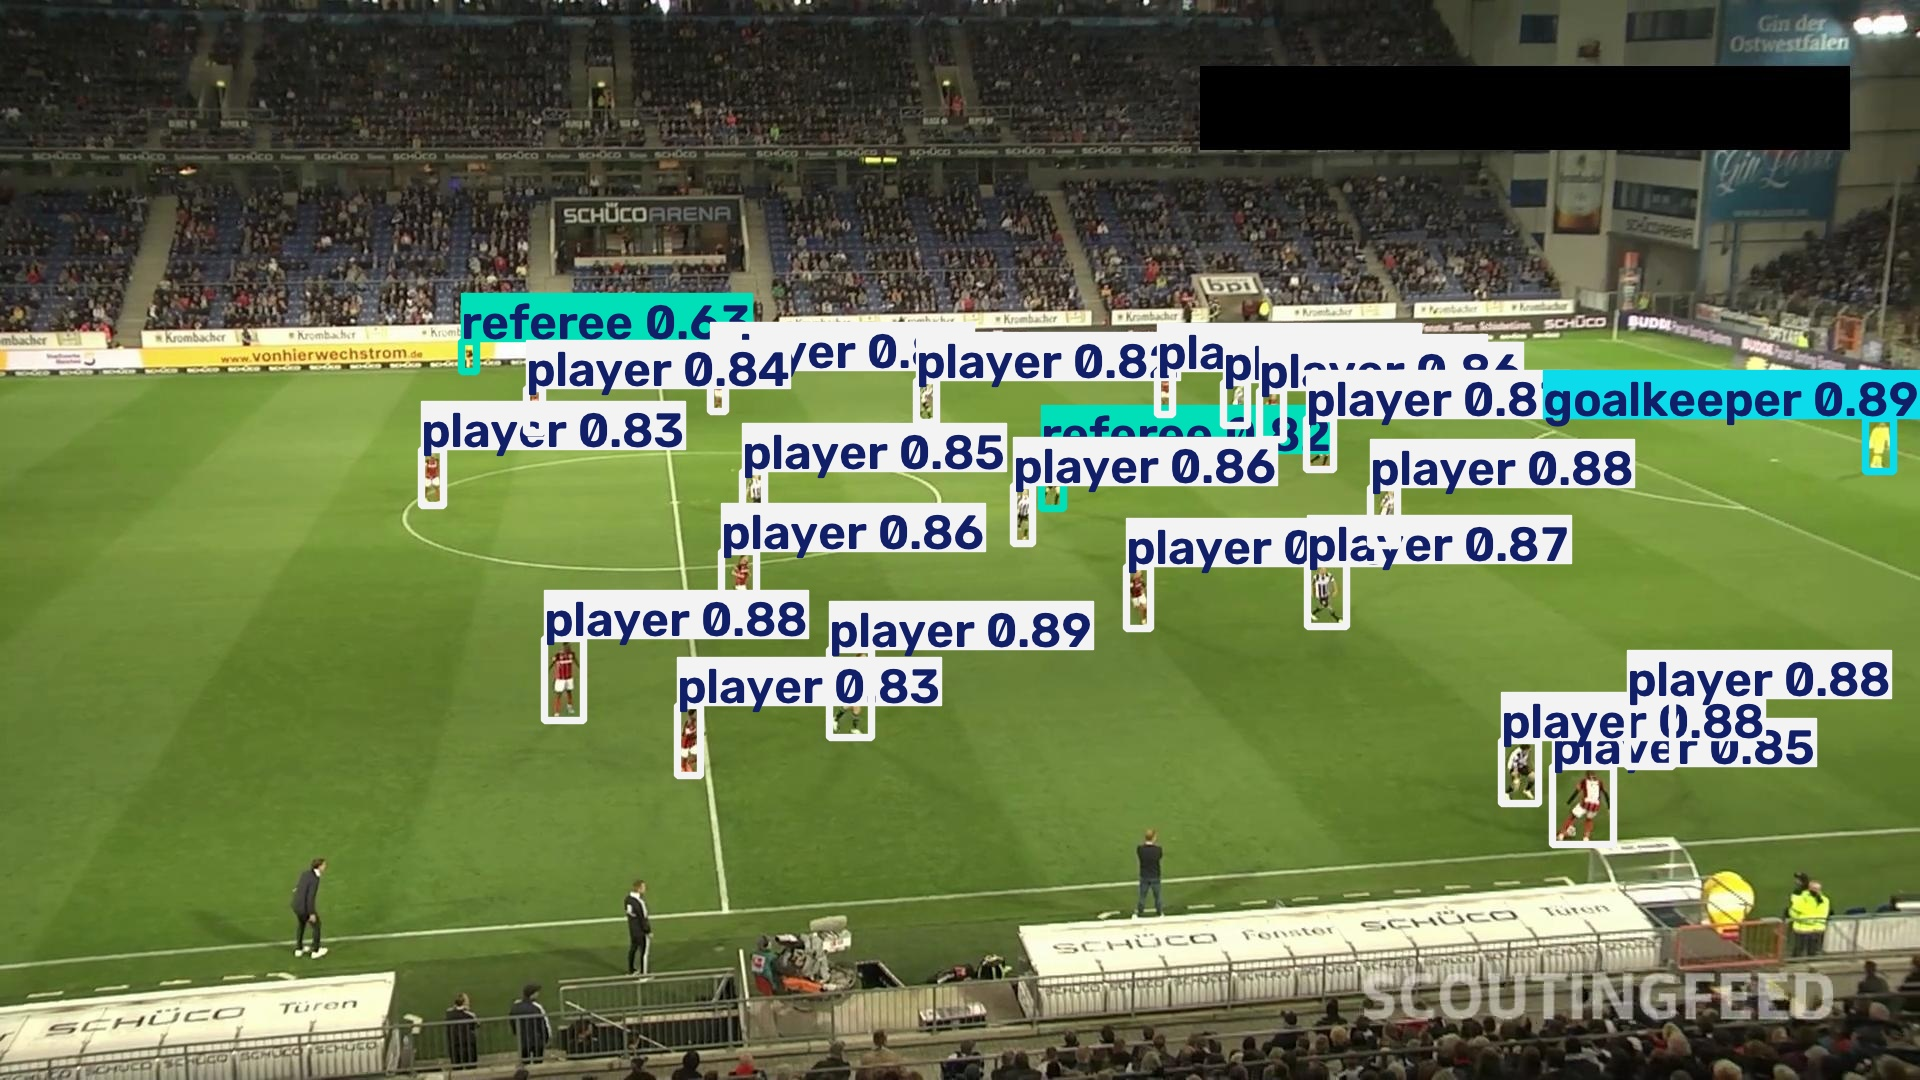

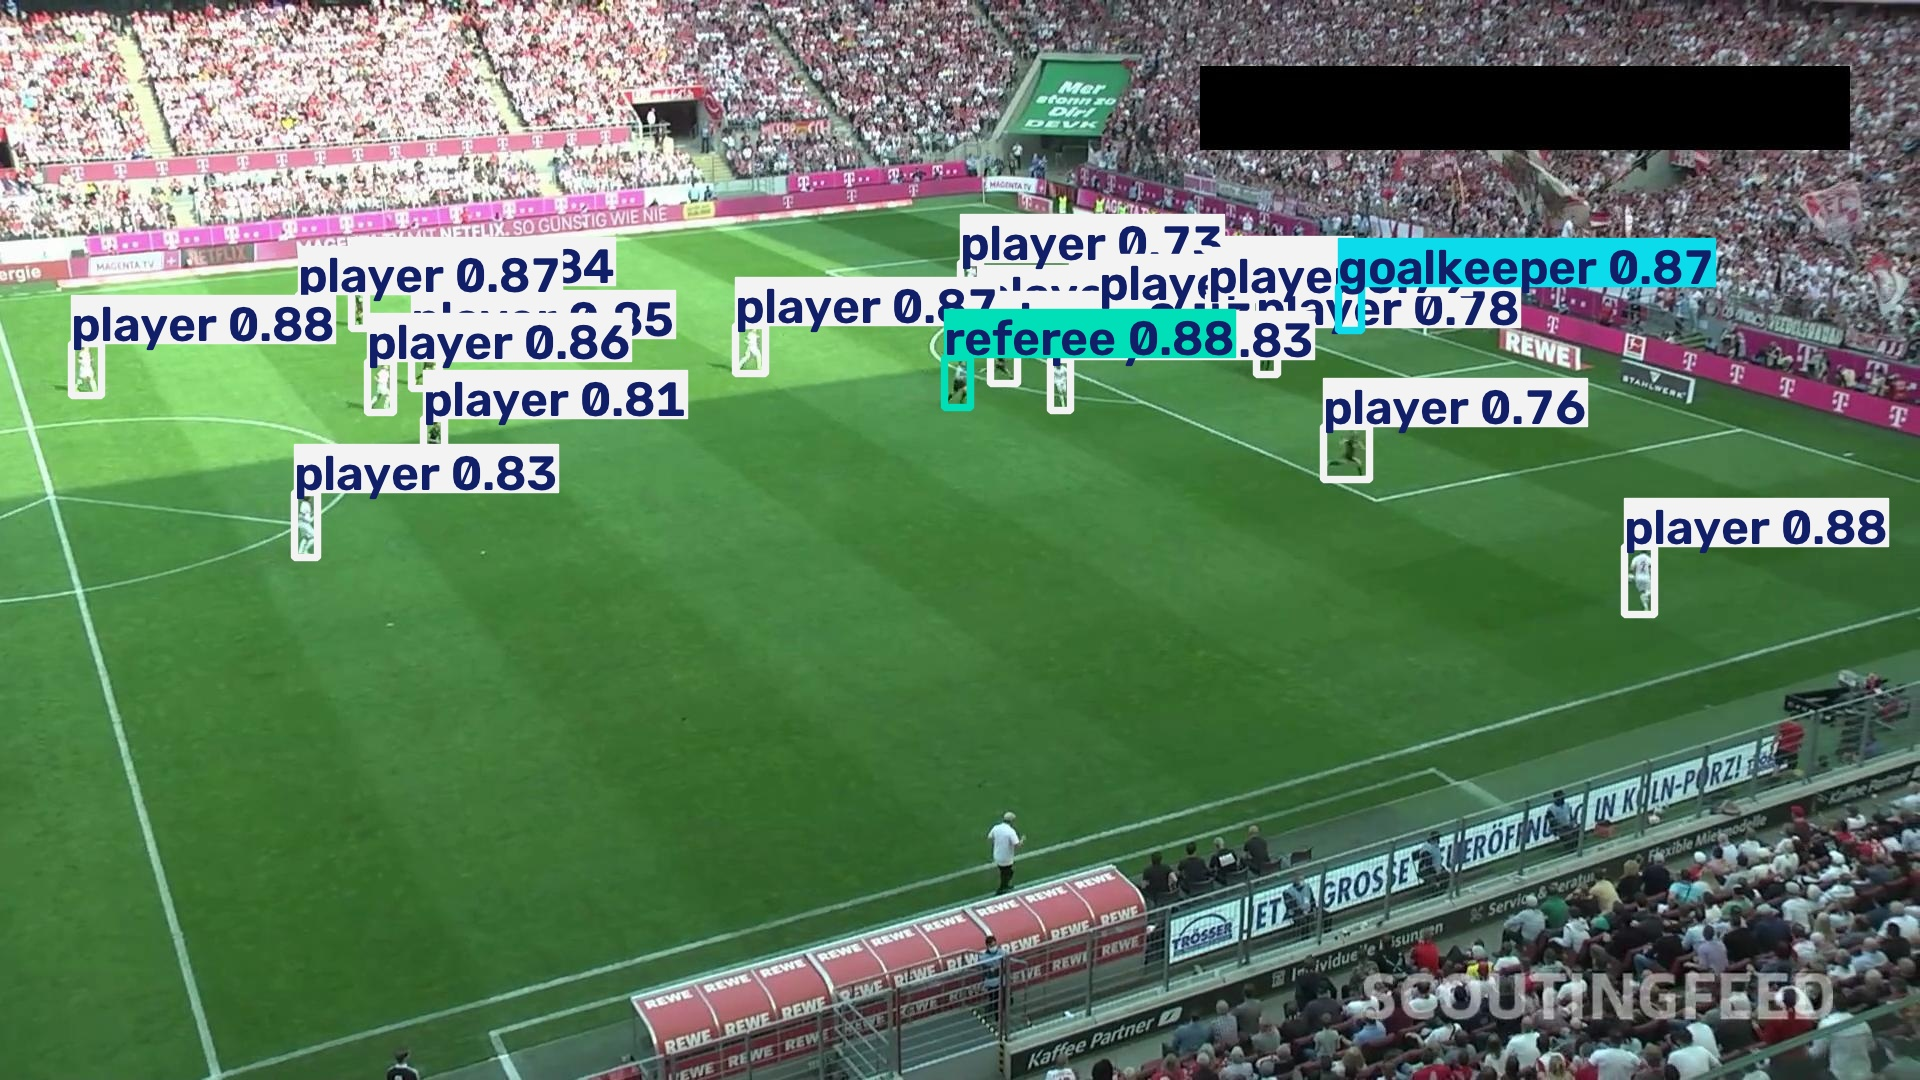

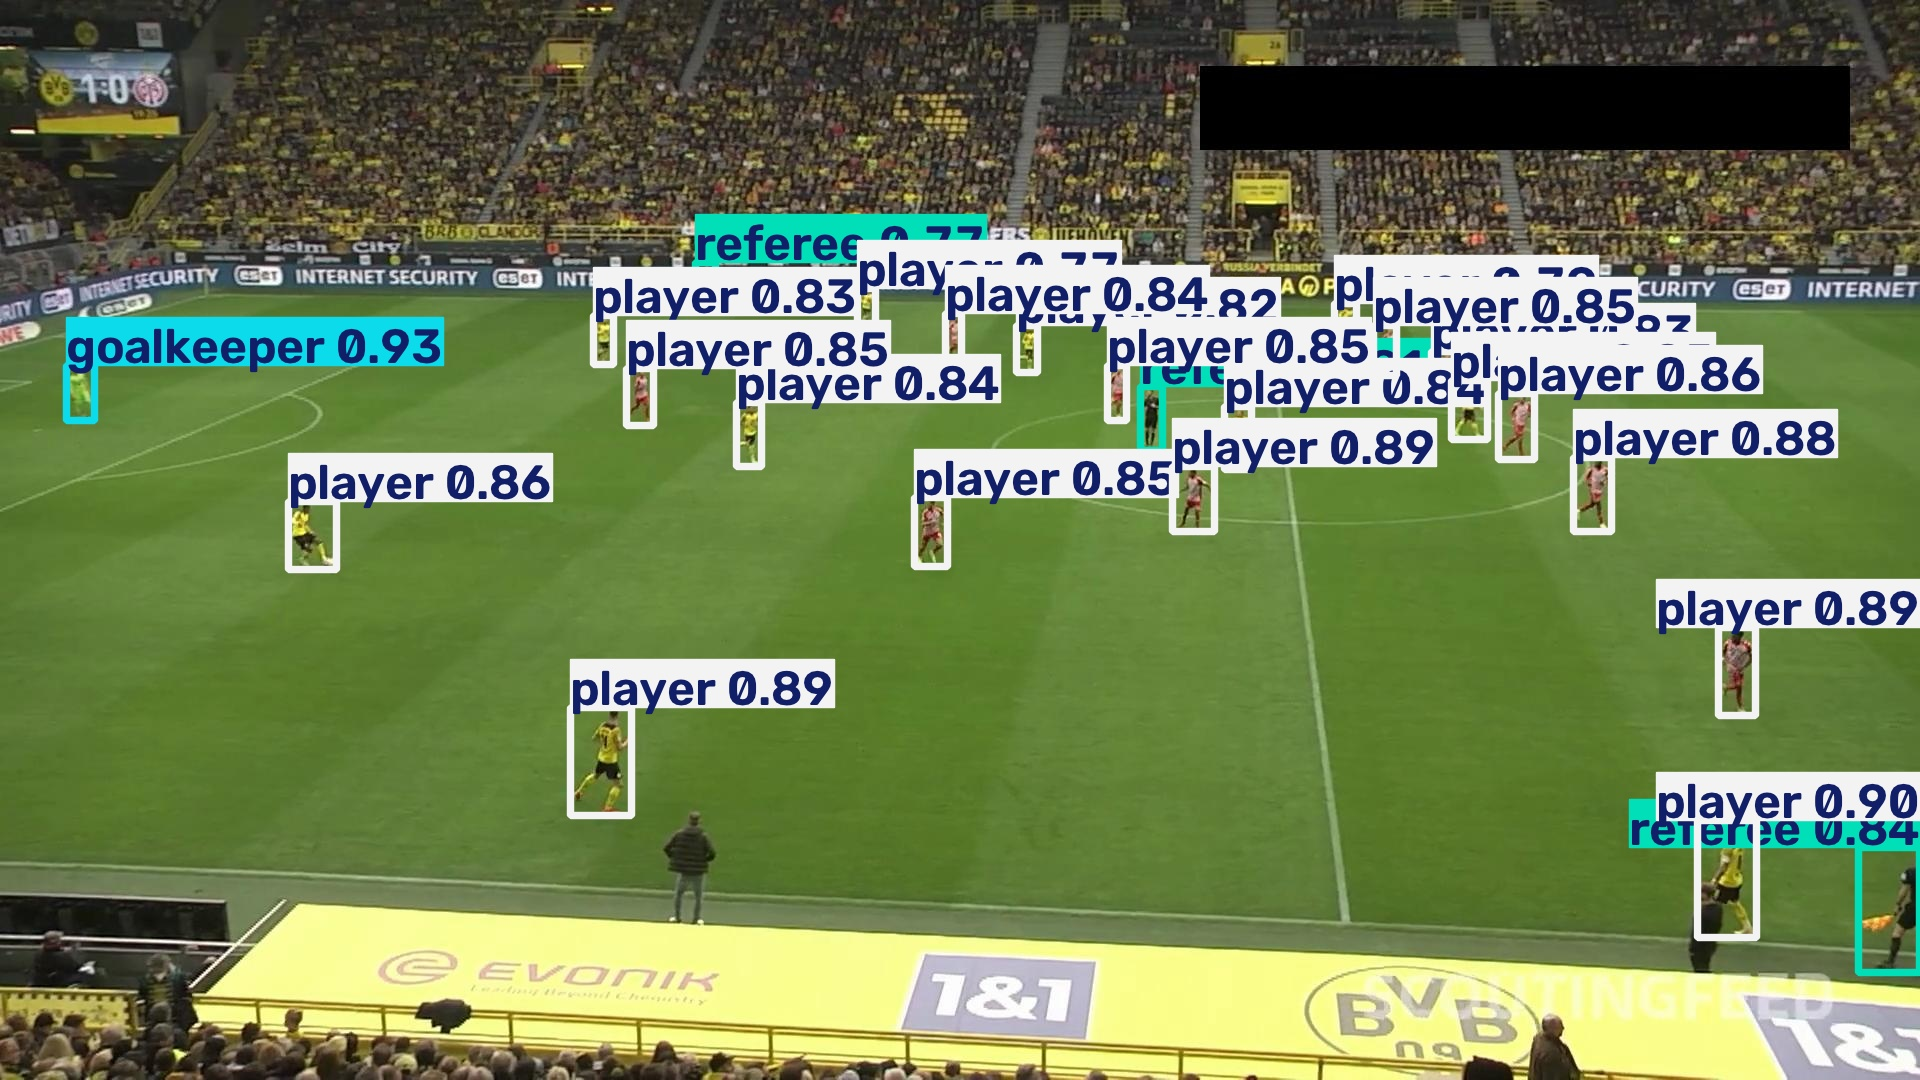

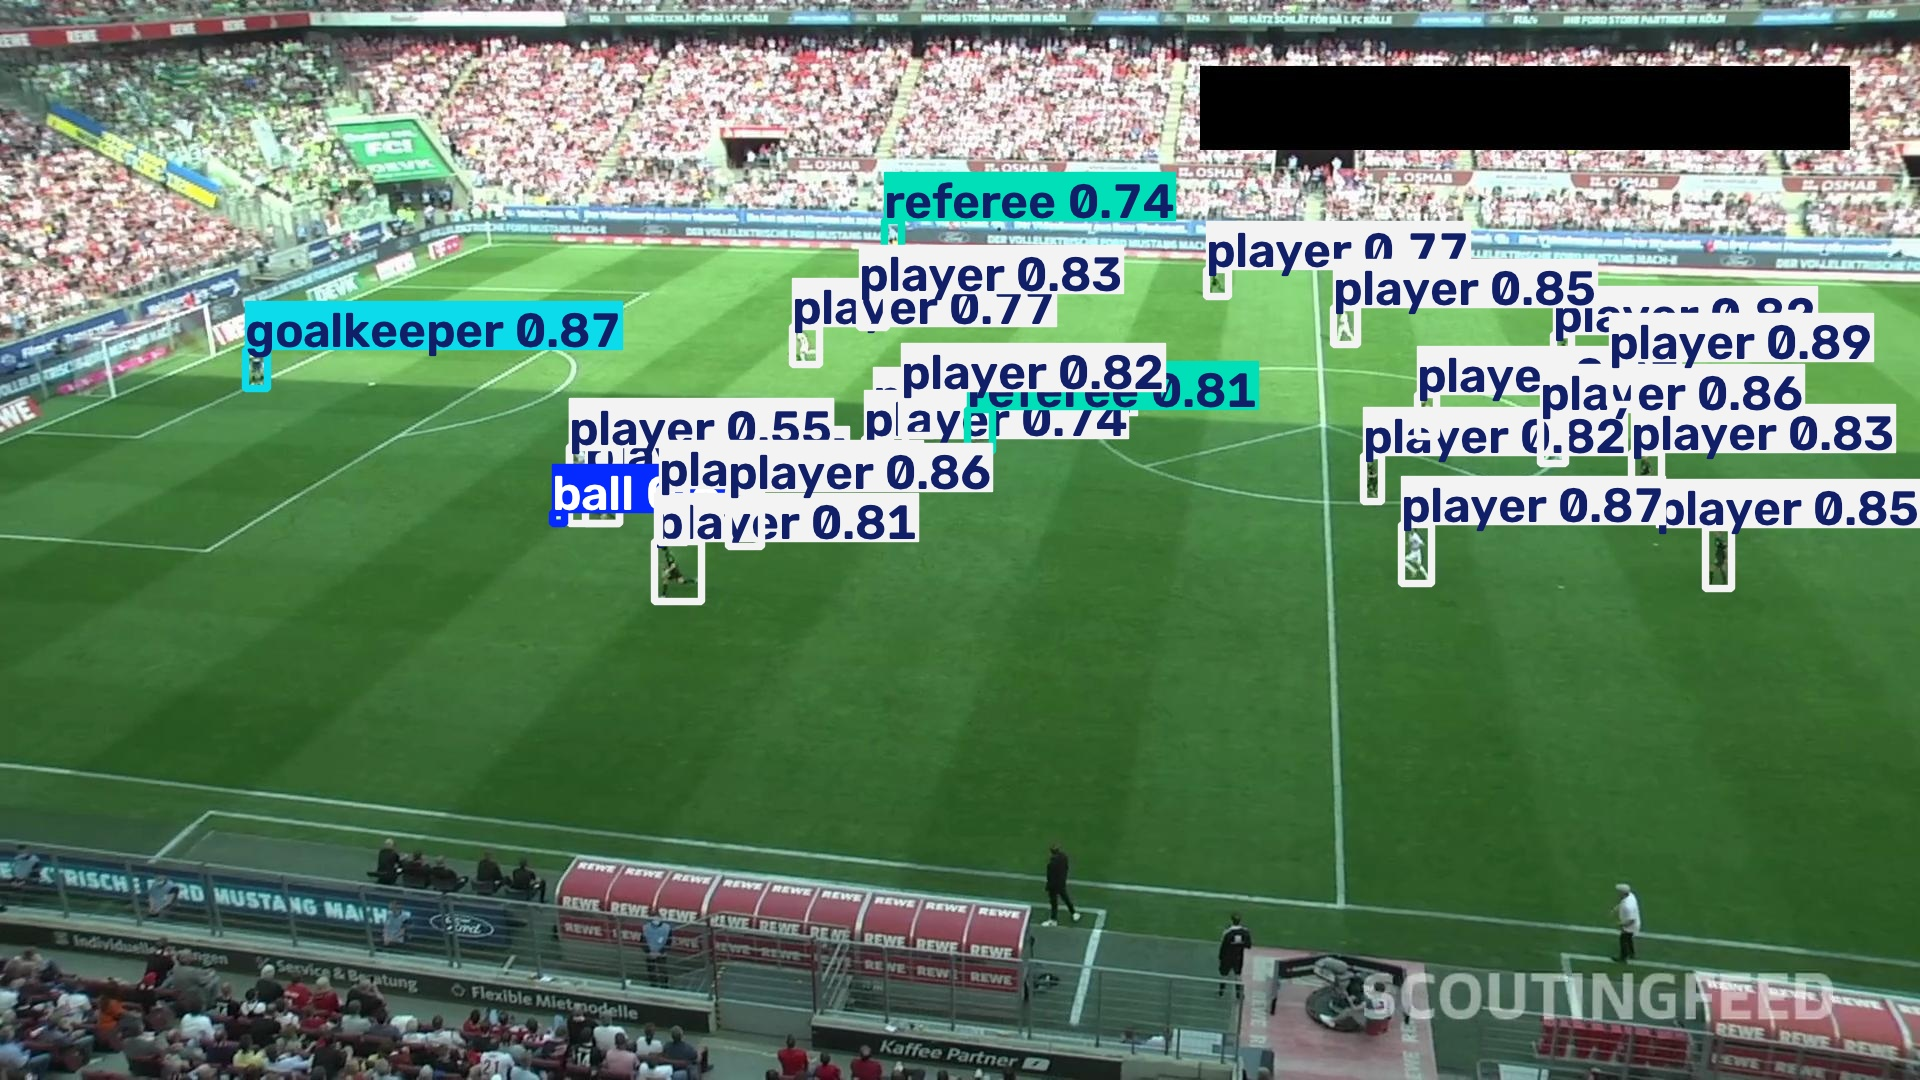

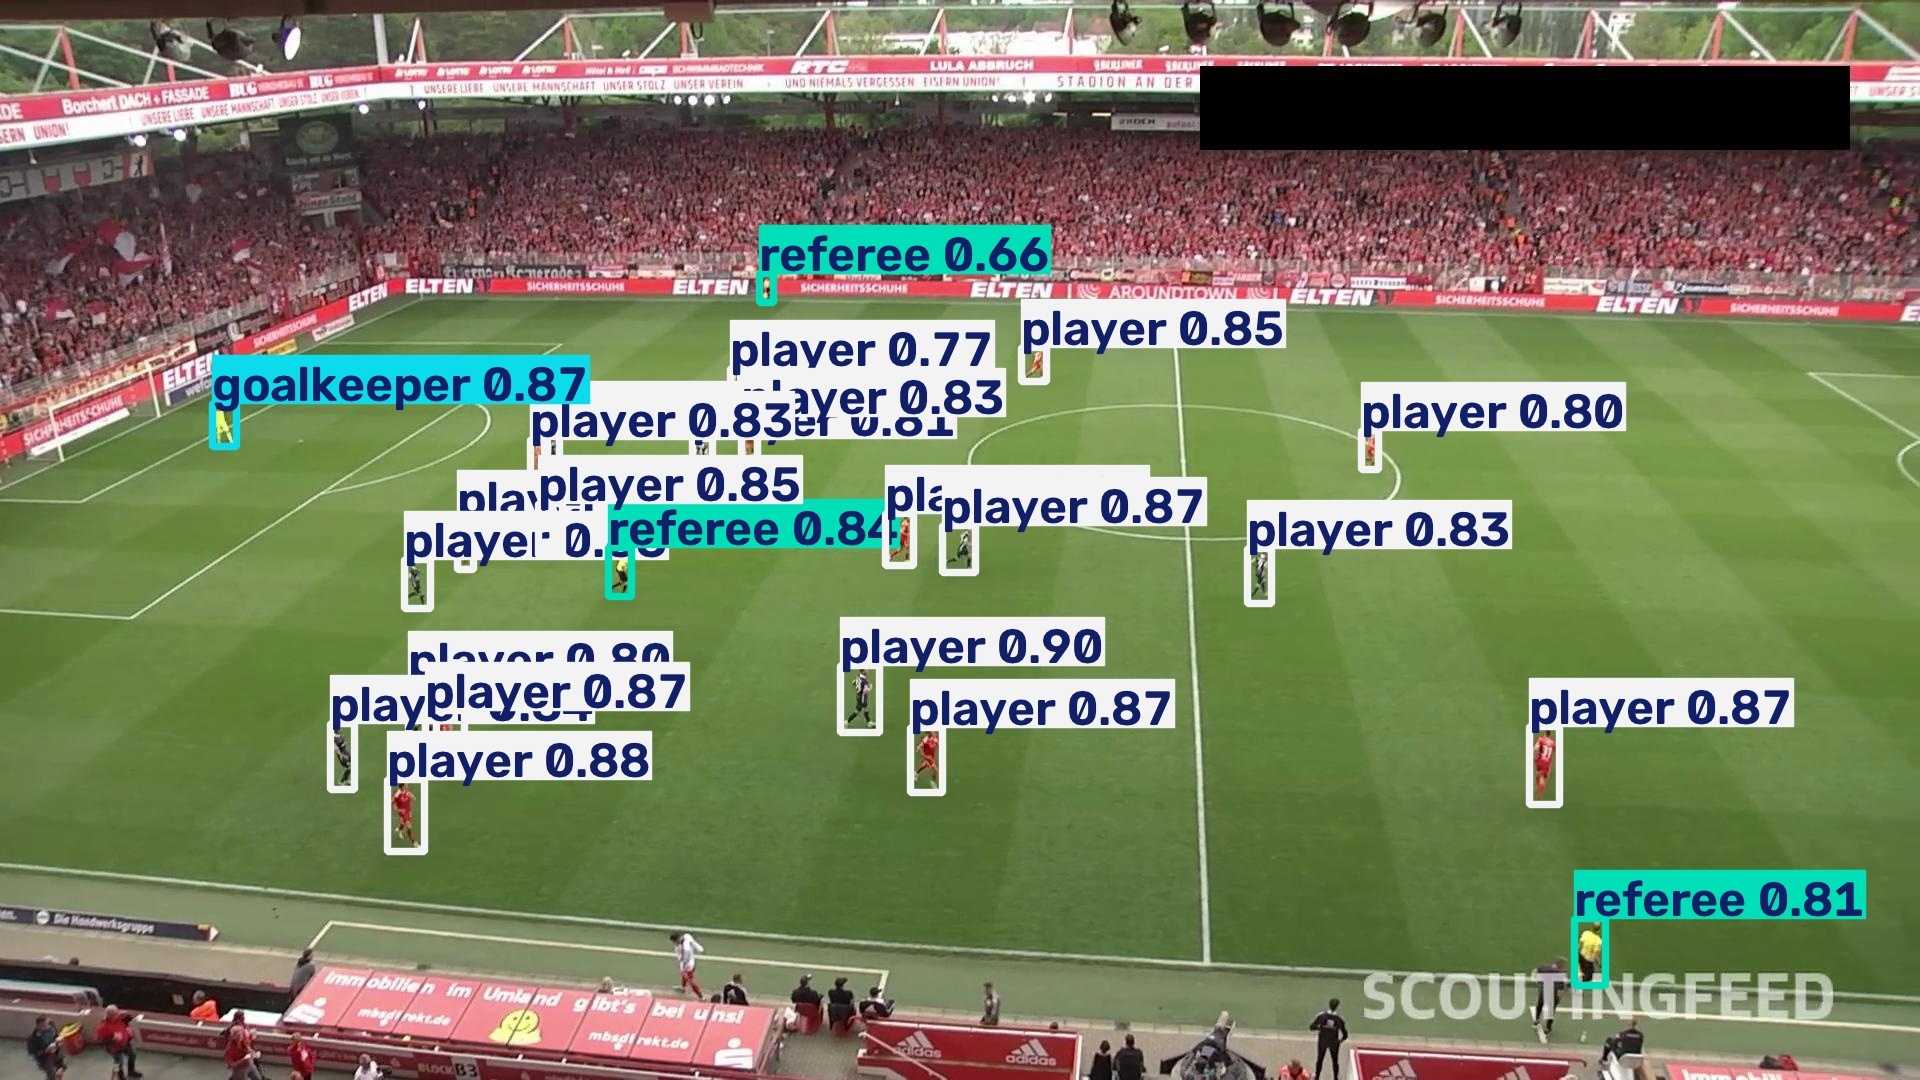

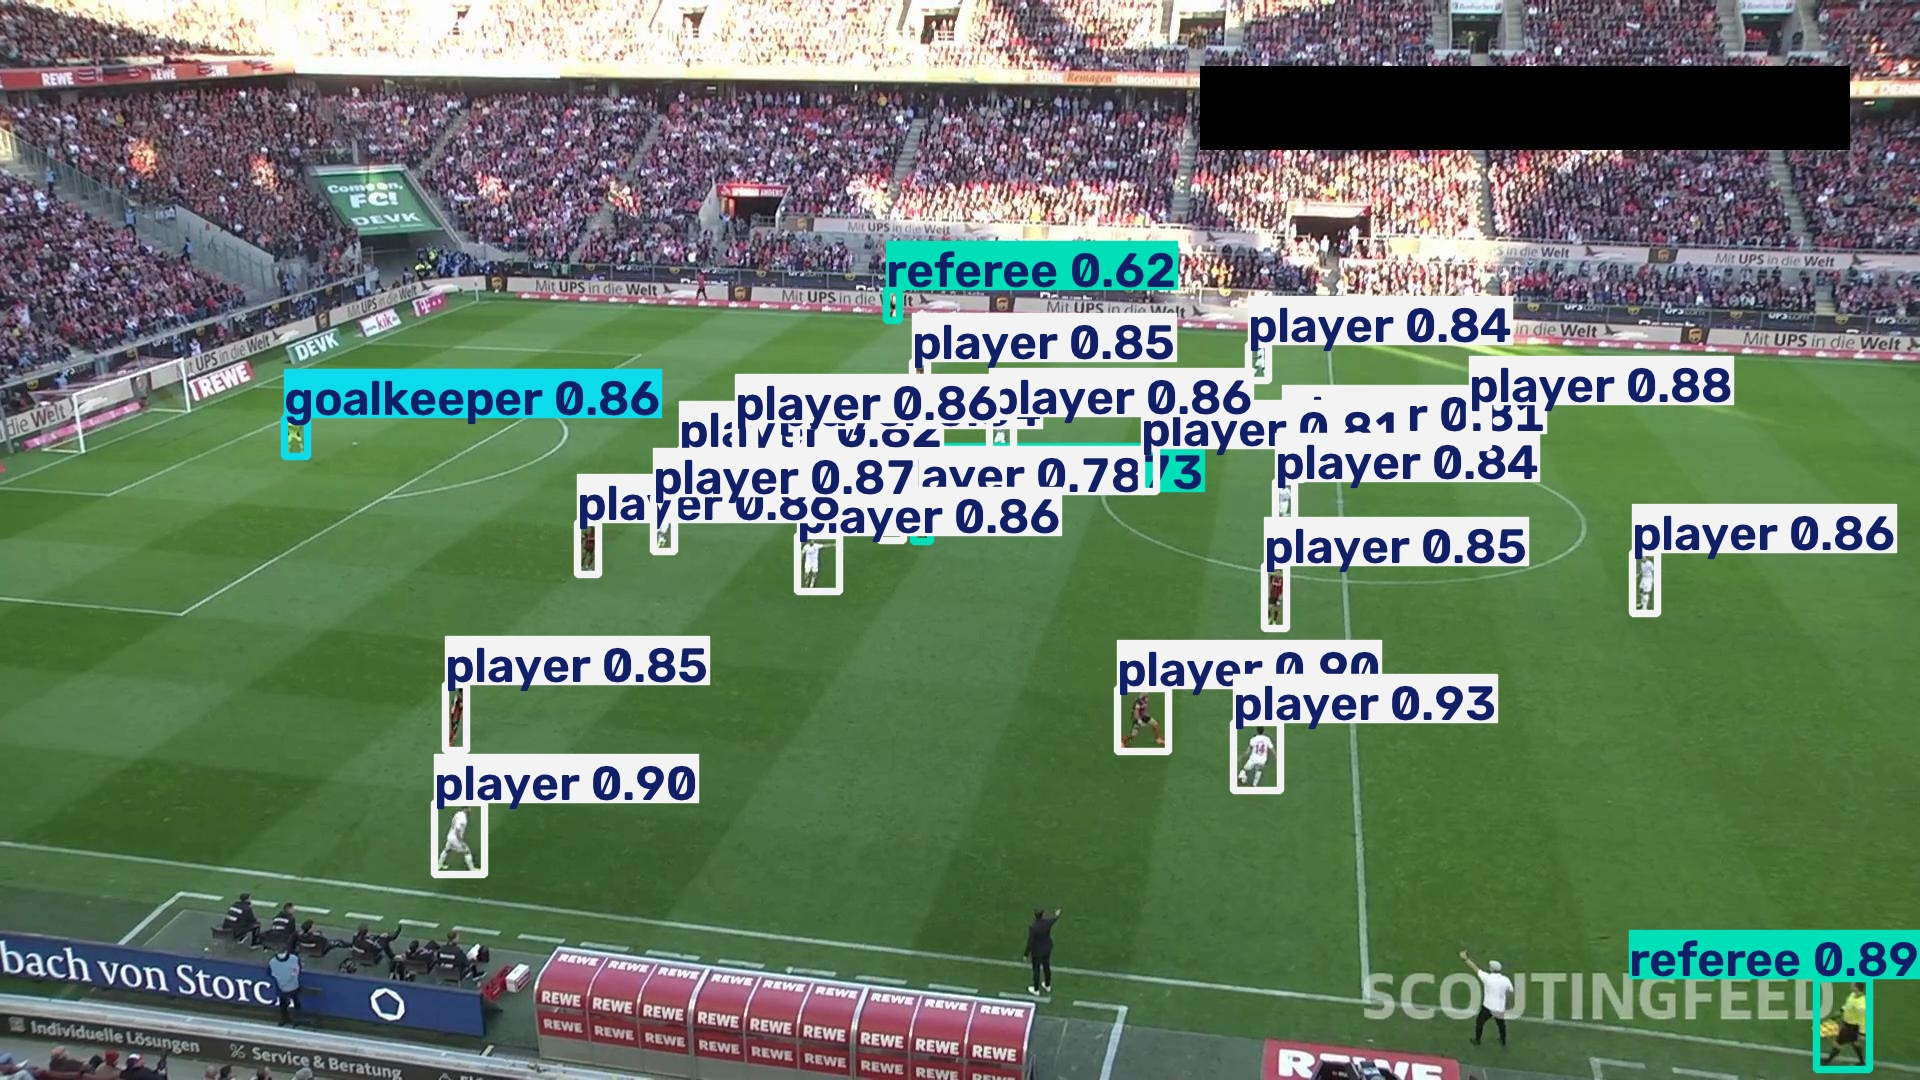

In [ ]:
import glob
from IPython.display import Image, display

prediction_images = []

for extension in ["*.jpg", "*.jpeg", "*.png", "*.webp"]:
    prediction_images.extend(
        glob.glob(str(PREDICTION_DIR / extension))
    )

for image_path in prediction_images[:10]:
    display(Image(filename=image_path, width=700))


In [ ]:
import pandas as pd
from ultralytics import YOLO
from pathlib import Path

# Carrega o modelo com os melhores pesos
best_model_path = "/content/runs_players/player_detector/weights/best.pt"
model = YOLO(best_model_path)

# Executa a validação no conjunto de validação para obter os resultados numéricos estruturados
metrics = model.val(data="/content/Dataset/data.yaml")

# Extrai as métricas globais e por classe
class_names = metrics.names
results_dict = {
    "Classe": [],
    "Precisão (P)": [],
    "Recall (R)": [],
    "mAP50": [],
    "mAP50-95": []
}

# Adiciona métricas de cada classe individual
for i, name in class_names.items():
    results_dict["Classe"].append(name)
    results_dict["Precisão (P)"].append(metrics.class_result(i)[0])
    results_dict["Recall (R)"].append(metrics.class_result(i)[1])
    results_dict["mAP50"].append(metrics.class_result(i)[2])
    results_dict["mAP50-95"].append(metrics.class_result(i)[3])

# Adiciona a média global (all)
results_dict["Classe"].append("all")
results_dict["Precisão (P)"].append(metrics.results_dict["metrics/precision(B)"])
results_dict["Recall (R)"].append(metrics.results_dict["metrics/recall(B)"])
results_dict["mAP50"].append(metrics.results_dict["metrics/mAP50(B)"])
results_dict["mAP50-95"].append(metrics.results_dict["metrics/mAP50-95(B)"])

# Cria e exibe um DataFrame formatado com os resultados
df_results = pd.DataFrame(results_dict)
print("\n--- RESULTADOS NUMÉRICOS DA VALIDAÇÃO ---\n")
display(df_results.round(4))

Ultralytics 8.4.163 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26s summary (fused): 120 layers, 9,466,728 parameters, 0 gradients, 20.8 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2570.7±543.6 MB/s, size: 233.8 KB)
val: Scanning /content/Dataset/valid/labels.cache... 38 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 38/38 12.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.0s/it 3.0s
                   all         38        905      0.982      0.812       0.87      0.657
                  ball         35         35      0.987      0.429      0.534      0.305
            goalkeeper         27         27      0.973      0.926      0.982      0.806
                player         38        754      0.982      0.979      0.985      0.817
               referee         38         89      0.988      0.913      0.979      0.698
Speed: 8.2ms preprocess, 18.1ms inference, 0.3ms

,Classe,Precisão (P),Recall (R),mAP50,mAP50-95
0,ball,0.9869,0.4286,0.5340,0.3053
1,goalkeeper,0.9727,0.9259,0.9817,0.8061
2,player,0.9822,0.9788,0.9847,0.8172
3,referee,0.9878,0.9134,0.9791,0.6976
4,all,0.9824,0.8117,0.8699,0.6565


compactar modelo

In [ ]:
from pathlib import Path
import shutil
import zipfile

BEST_MODEL_PATH = Path(
    "/content/runs_players/player_detector/weights/best.pt"
)

RUN_PATH = Path("/content/runs_players/player_detector")
OUTPUT_DIR = Path("/content/custom_model")
ZIP_PATH = Path("/content/player_detector.zip")

if not BEST_MODEL_PATH.exists():
    raise FileNotFoundError(
        f"Modelo não encontrado: {BEST_MODEL_PATH}"
    )

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

shutil.copy2(
    BEST_MODEL_PATH,
    OUTPUT_DIR / "player_detector.pt"
)

shutil.copytree(
    RUN_PATH,
    OUTPUT_DIR / "training_run",
    dirs_exist_ok=True
)

with zipfile.ZipFile(ZIP_PATH, "w", zipfile.ZIP_DEFLATED) as zip_file:
    for file_path in OUTPUT_DIR.rglob("*"):
        if file_path.is_file():
            zip_file.write(
                file_path,
                file_path.relative_to(OUTPUT_DIR)
            )

print("Arquivo criado:", ZIP_PATH)


Arquivo criado: /content/player_detector.zip


**4.1 Training Parameters**

<br/>

**1-Model architecture & size (`model`):**

There are several YOLO26 models sizes available to train, including `yolo26n-obb.pt` `yolo26s-obb.pt` `yolo26m-obb.pt` `yolo26l-obb.pt` `yolo26x-obb.pt` . Larger models run slower but have higher accuracy, while smaller models run faster but have lower accuracy.
If you aren't sure which model size to use, `yolo26s.pt` is a good starting point.



<br/>

**2-Number of epochs (`epochs`)**

In machine learning, one “epoch” is one single pass through the full training
| | Goal | Dataset Size | Recommended Epochs | Notes |
|:---:|------|--------------|-------------------|-------|
| 🧪 | Quick Prototype | Any | 20–30 | Just testing if pipeline works |
| 🟡 | Low Accuracy | < 200 images | 40–60 | Baseline usable model |
| 🟠 | Mid Accuracy | 200–500 images | 60–100 | Good balance of speed vs. quality |
| 🟢 | High Accuracy | 500–2000 images | 100–150 | Use best.pt, monitor mAP |
| 🔵 | Production Quality | 2000+ images | 150–300 | Diminishing returns after ~200 |
| ⚠️ | Overfitting Risk Zone | Any | 300+ | Only if val loss is still improving |

<br/>

3- **Resolution guid (`imgsz`)**

Resolution has a large impact on the speed and accuracy of the model: a lower resolution model will have higher speed but less accuracy.

| Resolution | Use Case | Object Size | Speed | Accuracy | VRAM Usage |
|:----------:|----------|:-----------:|:-----:|:--------:|:----------:|
| **320×320** | Edge devices, real-time IoT | Large objects only | ⚡⚡⚡⚡ Very Fast | ⭐ Low | 🟢 Very Low |
| **480×480** | Mobile apps, low-power GPUs | Medium–Large | ⚡⚡⚡ Fast | ⭐⭐ Medium-Low | 🟢 Low |
| **640×640** | ✅ Default / General purpose | Medium objects | ⚡⚡ Moderate | ⭐⭐⭐ Good | 🟡 Moderate |
| **800×800** | Detailed scenes, mid-size objects | Small–Medium | ⚡ Slower | ⭐⭐⭐⭐ High | 🟠 High |
| **1280×1280** | Drone footage, sports balls, screws | Small objects | 🐢 Slow | ⭐⭐⭐⭐⭐ Very High | 🔴 High |
| **1920×1920** | Microscopy, PCB inspection, tiny defects | Extremely small | 🐢🐢 Very Slow | ⭐⭐⭐⭐⭐ Max | 🔴🔴 Extreme |

<br/>

**Real-World Scenario Guide**

| Scenario | Recommended Resolution | Why |
|----------|----------------------|-----|
| 🎾 Sports ball tracking | **1280×1280** | Balls are tiny in wide-angle footage |
| 🔩 Defect / screw detection | **1280–1920** | Sub-centimeter details matter |
| 🚗 Car / vehicle detection | **640×640** | Cars are large, default works great |
| 🚶 Person detection (crowd) | **800×800** | People can be small in wide shots |
| 🍬 Candy / product counting | **640×640** | Objects fill reasonable frame space |
| 🛸 Drone aerial surveillance | **1280×1280** | Camera is far, objects appear tiny |
| 🏭 Assembly line inspection | **800–1280** | Depends on part size |
| 📱 Phone/webcam real-time | **480×480** | Prioritize speed for live feed |
| 🍓 Fruit sorting (close-up) | **640×640** | Objects are close and large enough |
| 🔬 Medical / microscopy | **1280–1920** | Tiny structures need max detail |


<br/> <br/>